# # BLOCK 1 — Install and Import Libraries

In [1]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install tensorflow matplotlib -q

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# # BLOCK 2 — Load and Preprocess Dataset

In [2]:
# ============================================================
# LOAD MNIST DATASET
# ============================================================

(X_train, _), (_, _) = mnist.load_data()

# ============================================================
# PREPROCESS DATASET
# ============================================================

X_train = X_train.reshape(
    X_train.shape[0],
    28,
    28,
    1
).astype('float32')

X_train = (X_train - 127.5) / 127.5

print("Dataset Shape :", X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset Shape : (60000, 28, 28, 1)


# # BLOCK 3 — Display Real Images

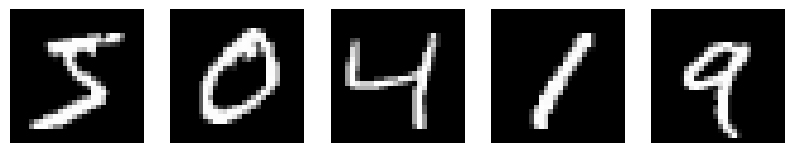

In [3]:
# ============================================================
# DISPLAY REAL DIGITS
# ============================================================

plt.figure(figsize=(10,2))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        X_train[i].reshape(28,28),
        cmap='gray'
    )

    plt.axis('off')

plt.show()

# # BLOCK 4 — Build Generator Model

In [4]:
# ============================================================
# GENERATOR MODEL
# ============================================================

generator = tf.keras.Sequential([

    layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),

    layers.BatchNormalization(),

    layers.LeakyReLU(),

    layers.Reshape((7,7,256)),

    layers.Conv2DTranspose(
        128,
        (5,5),
        strides=(1,1),
        padding='same',
        use_bias=False
    ),

    layers.BatchNormalization(),

    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        64,
        (5,5),
        strides=(2,2),
        padding='same',
        use_bias=False
    ),

    layers.BatchNormalization(),

    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        1,
        (5,5),
        strides=(2,2),
        padding='same',
        use_bias=False,
        activation='tanh'
    )
])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

# # BLOCK 5 — Build Discriminator Model

In [5]:
# ============================================================
# DISCRIMINATOR MODEL
# ============================================================

discriminator = tf.keras.Sequential([

    layers.Conv2D(
        64,
        (5,5),
        strides=(2,2),
        padding='same',
        input_shape=[28,28,1]
    ),

    layers.LeakyReLU(),

    layers.Dropout(0.3),

    layers.Conv2D(
        128,
        (5,5),
        strides=(2,2),
        padding='same'
    ),

    layers.LeakyReLU(),

    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(1)
])

discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# # BLOCK 6 — Define Loss and Optimizers

In [6]:
# ============================================================
# LOSS FUNCTIONS
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

generator_optimizer = tf.keras.optimizers.Adam(1e-4)

discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

print("Loss Functions Ready")

Loss Functions Ready


# # BLOCK 7 — Training Step

In [7]:
# ============================================================
# TRAINING STEP
# ============================================================

BATCH_SIZE = 256

noise_dim = 100

train_dataset = tf.data.Dataset.from_tensor_slices(
    X_train
).shuffle(60000).batch(BATCH_SIZE)

@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)

        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

# # BLOCK 8 — Train GAN Model

In [8]:
# ============================================================
# TRAIN GAN
# ============================================================

EPOCHS = 50

for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

    if (epoch + 1) % 5 == 0:

        print(f"\nEpoch : {epoch+1}")

        print(f"Generator Loss : {gen_loss:.4f}")

        print(f"Discriminator Loss : {disc_loss:.4f}")


Epoch : 5
Generator Loss : 0.8529
Discriminator Loss : 1.4268

Epoch : 10
Generator Loss : 0.9364
Discriminator Loss : 1.2088

Epoch : 15
Generator Loss : 0.9254
Discriminator Loss : 1.2982

Epoch : 20
Generator Loss : 0.9973
Discriminator Loss : 1.1098

Epoch : 25
Generator Loss : 1.1311
Discriminator Loss : 1.1649

Epoch : 30
Generator Loss : 1.2759
Discriminator Loss : 1.1530

Epoch : 35
Generator Loss : 1.0004
Discriminator Loss : 1.2254

Epoch : 40
Generator Loss : 1.0119
Discriminator Loss : 1.3054

Epoch : 45
Generator Loss : 0.9043
Discriminator Loss : 1.2413

Epoch : 50
Generator Loss : 1.0586
Discriminator Loss : 0.9565


# # BLOCK 9 — Generate Final Handwritten Digits

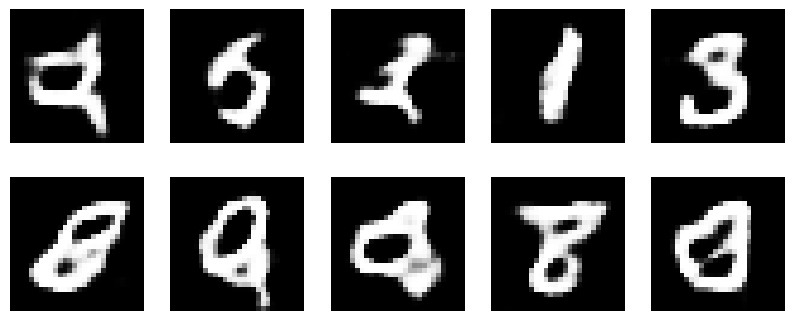

In [9]:
# ============================================================
# GENERATE HANDWRITTEN DIGITS
# ============================================================

noise = tf.random.normal([10, 100])

generated_images = generator(
    noise,
    training=False
)

plt.figure(figsize=(10,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        generated_images[i, :, :, 0] * 127.5 + 127.5,
        cmap='gray'
    )

    plt.axis('off')

plt.show()

# # BLOCK 10 — Final Conclusion

In [10]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("""
ASSIGNMENT COMPLETED SUCCESSFULLY

Experiment:
Deep Convolutional GAN (DCGAN)

Dataset Used:
MNIST Handwritten Digits Dataset

Components:
1. Generator
2. Discriminator
3. Adversarial Training

Observations:
- Generator creates realistic handwritten digits
- Discriminator identifies fake and real images
- GAN improves continuously through training

Applications:
- Image Generation
- AI Art
- Deepfake Technology
- Medical Imaging
- Synthetic Data Generation
""")


ASSIGNMENT COMPLETED SUCCESSFULLY

Experiment:
Deep Convolutional GAN (DCGAN)

Dataset Used:
MNIST Handwritten Digits Dataset

Components:
1. Generator
2. Discriminator
3. Adversarial Training

Observations:
- Generator creates realistic handwritten digits
- Discriminator identifies fake and real images
- GAN improves continuously through training

Applications:
- Image Generation
- AI Art
- Deepfake Technology
- Medical Imaging
- Synthetic Data Generation

